## Timeseries Decomposition of MODIS NDVI to detect long term changes

## Packages/Libraries

In [2]:
from functions.decompose import decompose
from functions.multiannual_timeseries import *
import matplotlib.pyplot as plt
from functions.mk_test import *
import xarray as xr

## Get MODIS

In [3]:
dc = multiannual_timeseries(aoi_path=r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\gis\geodata\bioreservat_rhön.geojson", start_year=2000, end_year=2001,landcover_code=[60])

Searching MODIS catalog for 16 day resolution
Found 43 items (17.88 MB
Searching LC catalog
landcover loaded
datacube clipped


KeyboardInterrupt: 

## Decomposition

In [3]:
decomposition= decompose(dc)

Save = True
if Save: decomposition["trend"].rio.set_spatial_dims(x_dim="longitude", y_dim="latitude").rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests/trend00_24.tif")
if Save: decomposition["residual"].rio.set_spatial_dims(x_dim="longitude", y_dim="latitude").rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests/residual00_24.tif")
if Save: decomposition["seasonal"].rio.set_spatial_dims(x_dim="longitude", y_dim="latitude").rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests/seasonal00_24.tif")

    ## Plot Mean Decomposition

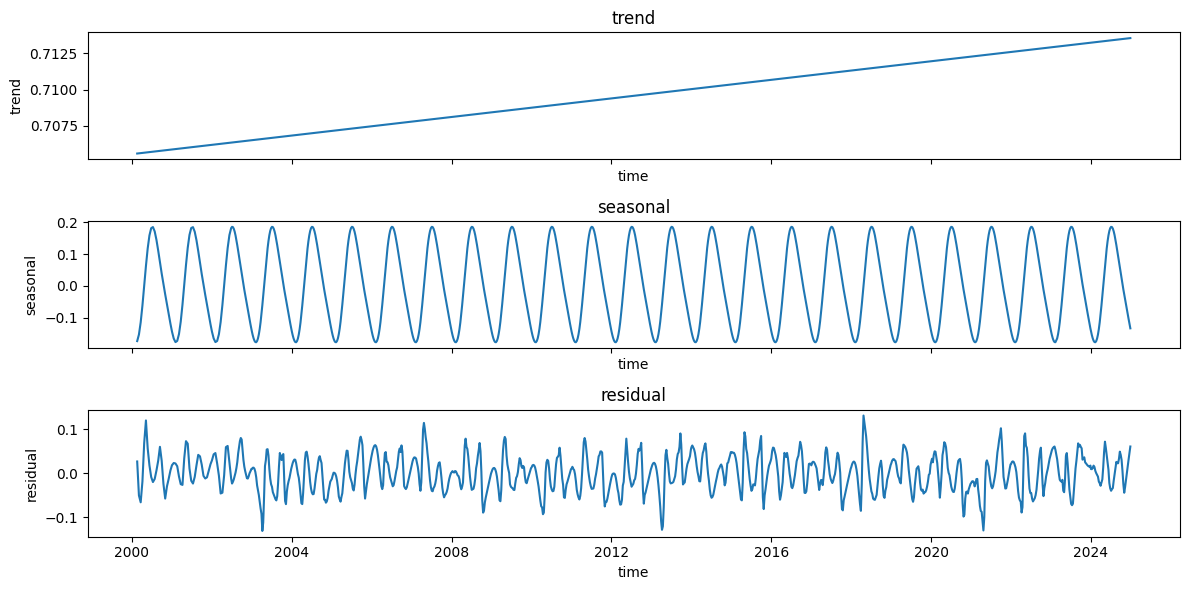

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, var in zip(axes, ["trend", "seasonal", "residual"]):
    decomposition.mean(dim=["latitude", "longitude"])[var].plot(ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

## Mann-Kendall

In [11]:
mk_results = mk_test(decomposition)

trend_slope = mk_results[0]
increase = mk_results[1]
decrease = mk_results[2]

multiband_da = xr.concat([trend_slope, increase, decrease], dim="band")
multiband_da = multiband_da.assign_coords(band=[1, 2, 3])
multiband_da.coords["band_name"] = ("band", ["trend_slope", "increase", "decrease"])

Save = False
if Save:
    multiband_da.rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests\mk_0020_multiband.tif")